# Project Phase I — Student Dropout

| Field | Entry |
|---|---|
| Project title | Student Dropout Rate |
| Group members | Anas — 24253881 · Hasan — 24245408 · Aaron Taylor — 24232594 |
| Analytical objective | Investigate the factors and group relationships that may have influenced Graduate, Dropout, or Enrolled students. |
| Dataset name | Predict Students' Dropout and Academic Success |
| Phase | Project Phase I (problem, acquisition, cleaning, EDA only)


## Setup

In [2]:
import importlib.util
import subprocess
import sys

# Module name for import checks, pip name for install (sklearn != scikit-learn)
required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}
missing = [pip_name for mod, pip_name in required_packages.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)

Python: 3.14.6
pandas: 3.0.3


# Task 1: Problem Definition and Dataset Selection

## 1.1 Define the real-world problem


**Problem statement:**  We aim to identify students who are at risk of dropping out, based on academic, demographic, and socio-economic factors, so struggling students can get help before it's too late.

**Analytical objective:** Predict student dropout risk.


## 1.2 Motivation, background, stakeholders, and practical relevance

| Item | Notes |
|---|---|
| Motivation | Student dropout is a persistent problem for higher education institutions - it affects funding, rankings, and most importantly, students' futures. Identifying at-risk students early gives institutions a chance to intervene before it's too late. |
| Background | Dropout and retention rates are widely used indicators of institutional performance and are increasingly tied to government funding and accreditation. Many institutions still rely on outdated processes to identify struggling students, rather than data-driven approaches. |
| Stakeholders |  University administrators and academic advisors (to plan interventions), lecturers/tutors (to identify students needing support), students themselves (who benefit from earlier support) and policymakers (who track retention/graduation rates for funding and accreditation). |
| Practical relevance | A model that predicts student dropout rate could be integrated into a student support system to flag at-risk students early in their studies, allowing advisors to prioritize outreach, counseling or academic support resources toward those most likely to need it. |


## 1.3 Dataset selection and suitability checks

| Check | Evidence |
|---|---|
| Dataset name | Predict Students' Dropout and Academic Success |
| Source URL | https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success |
| Tabular / alpha-numeric | Yes — numeric codes, continuous measurements, and a text target label |
| Initial feature count | 36 predictors + 1 target (`Target`) = 37 columns |
| Record count | 4424 |
| Target / label (if any) | `Target` — three classes: Graduate, Dropout, Enrolled |
| Why this dataset fits the problem | It combines enrolment-time demographics and socio-economic status with first- and second-semester academic performance, plus a labelled academic outcome. That is the information needed to investigate which students are at risk of dropping out. |


## 1.4 Dataset source, access date, licence, and documentation

| Field | Entry |
|---|---|
| Dataset source | UC Irvine Machine Learning Repository |
| Direct download link | https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip |
| Access date | 30 August 2026 (local copy stored in `data/data.csv`) |
| Licence / terms of use | Creative Commons Attribution 4.0 International (CC BY 4.0) |
| Documentation / data dictionary | UCI dataset page: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success · paper: Realinho et al., Data 7(11):146, 2022, https://doi.org/10.3390/data7110146 · full variable codes are in the Data Key section at the end of this notebook |
| How data were collected (brief) | Merged from a Portuguese higher-education institution: CNAES enrolment records, the Academic Management System (student records and evaluations), and macroeconomic indicators from PORDATA. Students were labelled Graduate, Dropout, or Enrolled at the end of the normal course duration. |
| Privacy / anonymisation notes | The published file contains no student names, IDs, or other direct identifiers. Personal identifiers were removed by the data providers before release. |


## 1.5 Lecturer approval

| Item | Status |
|---|---|
| Approval form submitted | Yes |
| Lecturer decision | Approved |
| Notes from feedback | None recorded |


# Task 2: Data Acquisition, Inspection, and Documentation


## 2.1 Loading the dataset 

In [3]:
DATA_PATH = "data/data.csv"  # Imported Data Set

df = pd.read_csv(DATA_PATH,sep=";")  # Code is semiColon separated
df_original = df.copy(deep=True)

print("Shape:", df.shape)
df.head()

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.2 Describe the dataset structure 


| Item | Result |
|---|---|
| Number of records | 4424 |
| Number of features | 37 columns (36 predictors + 1 target) |
| Data types summary | 29 integer, 7 float, 1 text (`Target`) |
| Target column | Academic outcome — Graduate / Dropout / Enrolled |



**Variable meanings:** brief list of key columns

 **Demographics / Background:** marital status, nationality, gender, age, international, displaced <br>
 **Application / Admission Detail:** application mode/order, course, daytime/evening, previous qualification & grade, admission grade <br>
 **Family:** mother’s/father’s qualification & occupation <br>
 **Financial / Support:** debtor, tuition up to date, scholarship <br>
 **Academic Performance:** 1st/2nd semester curricular units (credited, enrolled, evaluations, approved, grade, without evaluations) <br>
 **Macro Context:** unemployment rate, inflation rate, GDP <br>
 **Label (Target):** Academic Outcome (Graduate/Dropout/Enrolled)

## 2.3 Inspect quality and content

In [4]:
# Check overall structure / column types
print(df.info())
print("\nDtypes:\n", df.dtypes.value_counts())  # How many int / float / object columns

# Check missing values
missing = df.isna().sum().sort_values(ascending=False)  # Count of NaNs per column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)  # Missing as %
print("\nTop missing counts:\n", missing.head(20))
print("\nTop missing %:\n", missing_pct.head(20))

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())  # Exact full-row duplicates

# Check numeric value ranges (min / max / mean etc.)
display(df.describe(include="number").T)

# Check unique values for text / category columns
for col in df.select_dtypes(include=["str", "object", "category", "bool"]).columns:
    print(f"\n{col}: {df[col].nunique()} unique")  # How many distinct values
    print(df[col].value_counts(dropna=False).head(10))  # Most common values + Target balance

# Check coded columns stored as numbers (should be treated as categories later)
coded_cols = [
    "Marital status", "Application mode", "Course", "Gender", "Nacionality",
    "Displaced", "Debtor", "Scholarship holder", "International",
]
print("\nCoded columns (stored as int/float but categorical):")
for col in coded_cols:
    print(f"{col}: {df[col].nunique()} unique | min={df[col].min()} | max={df[col].max()}")

# Validate values against the data dictionary (see Data Key section)
attendance_col = [c for c in df.columns if c.startswith("Daytime/evening attendance")][0]
valid_codes = {
    "Marital status": {1, 2, 3, 4, 5, 6},
    "Application mode": {1, 2, 5, 7, 10, 15, 16, 17, 18, 26, 27, 39, 42, 43, 44, 51, 53, 57},
    "Application order": set(range(10)),  # 0 = first choice, 9 = last choice
    "Course": {33, 171, 8014, 9003, 9070, 9085, 9119, 9130, 9147, 9238, 9254, 9500, 9556, 9670, 9773, 9853, 9991},
    "Previous qualification": {1, 2, 3, 4, 5, 6, 9, 10, 12, 14, 15, 19, 38, 39, 40, 42, 43},
    "Nacionality": {1, 2, 6, 11, 13, 14, 17, 21, 22, 24, 25, 26, 32, 41, 62, 100, 101, 103, 105, 108, 109},
    "Mother's qualification": {1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 14, 18, 19, 22, 26, 27, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44},
    "Father's qualification": {1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 18, 19, 20, 22, 25, 26, 27, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44},
    "Mother's occupation": {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 90, 99, 122, 123, 125, 131, 132, 134, 141, 143, 144, 151, 152, 153, 171, 173, 175, 191, 192, 193, 194},
    "Father's occupation": {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 90, 99, 101, 102, 103, 112, 114, 121, 122, 123, 124, 131, 132, 134, 135, 141, 143, 144, 151, 152, 153, 154, 161, 163, 171, 172, 174, 175, 181, 182, 183, 192, 193, 194, 195},
    "Displaced": {0, 1},
    "Educational special needs": {0, 1},
    "Debtor": {0, 1},
    "Tuition fees up to date": {0, 1},
    "Gender": {0, 1},
    "Scholarship holder": {0, 1},
    "International": {0, 1},
    attendance_col: {0, 1},
    "Target": {"Graduate", "Dropout", "Enrolled"},
}
print("\nDictionary validation (invalid codes per column):")
for col, allowed in valid_codes.items():
    actual = set(df[col].unique())
    invalid = sorted(actual - allowed)
    print(f"{col}: {invalid if invalid else 'none'}")

# Check key ranges against expected scales from the data dictionary
print("\nPrevious qualification (grade):", df["Previous qualification (grade)"].min(), "to", df["Previous qualification (grade)"].max())  # Expected 0 to 200
print("Admission grade:", df["Admission grade"].min(), "to", df["Admission grade"].max())  # Expected 0 to 200
print("Age at enrollment:", df["Age at enrollment"].min(), "to", df["Age at enrollment"].max())
print("1st sem grade:", df["Curricular units 1st sem (grade)"].min(), "to", df["Curricular units 1st sem (grade)"].max())  # Expected 0 to 20
print("2nd sem grade:", df["Curricular units 2nd sem (grade)"].min(), "to", df["Curricular units 2nd sem (grade)"].max())  # Expected 0 to 20
print(df["Application order"].value_counts().sort_index())  # 0 = first choice, 9 = last choice

# Check column name quirks (BOM / trailing spaces / tabs)
print("\nColumn names:")
for c in df.columns:
    print(repr(c))  # Shows hidden characters in names

# Check simple logical inconsistencies (invalid / odd rows)
bad_1st = df[
    df["Curricular units 1st sem (approved)"]
    > df["Curricular units 1st sem (enrolled)"]
]  # Approved should not exceed enrolled
bad_2nd = df[
    df["Curricular units 2nd sem (approved)"]
    > df["Curricular units 2nd sem (enrolled)"]
]
grade_no_enroll_1st = df[
    (df["Curricular units 1st sem (enrolled)"] == 0)
    & (df["Curricular units 1st sem (grade)"] != 0)
]  # Grade should be 0 when no units enrolled
grade_no_enroll_2nd = df[
    (df["Curricular units 2nd sem (enrolled)"] == 0)
    & (df["Curricular units 2nd sem (grade)"] != 0)
]
print("\n1st sem approved > enrolled:", len(bad_1st))
print("2nd sem approved > enrolled:", len(bad_2nd))
print("1st sem grade != 0 with enrolled = 0:", len(grade_no_enroll_1st))
print("2nd sem grade != 0 with enrolled = 0:", len(grade_no_enroll_2nd))

# Check Target distribution
print("\nTarget counts:\n", df["Target"].value_counts())  # Graduate / Dropout / Enrolled


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



Target: 3 unique
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Coded columns (stored as int/float but categorical):
Marital status: 6 unique | min=1 | max=6
Application mode: 18 unique | min=1 | max=57
Course: 17 unique | min=33 | max=9991
Gender: 2 unique | min=0 | max=1
Nacionality: 21 unique | min=1 | max=109
Displaced: 2 unique | min=0 | max=1
Debtor: 2 unique | min=0 | max=1
Scholarship holder: 2 unique | min=0 | max=1
International: 2 unique | min=0 | max=1

Dictionary validation (invalid codes per column):
Marital status: none
Application mode: none
Application order: none
Course: none
Previous qualification: none
Nacionality: none
Mother's qualification: none
Father's qualification: none
Mother's occupation: none
Father's occupation: none
Displaced: none
Educational special needs: none
Debtor: none
Tuition fees up to date: none
Gender: none
Scholarship holder: none
International: none
Daytime/evening attendance	: none
Target: none

Previo

### Inspection findings

| Check | Finding |
|---|---|
| Data types issues | The dataset has 29 integer columns, 7 decimal columns, and 1 text column. The text column is the target outcome (`Target`). According to the data dictionary, most background fields are coded categories stored as integers (for example marital status, course, gender, and application mode). These should be treated as categorical variables in later cleaning and analysis, not as continuous numeric measurements. |
| Value ranges / odd extremes | Value ranges were checked against the data dictionary. Previous qualification grade and admission grade fall between 95.0 and 190.0, which is within the documented 0 to 200 scale. Semester grades fall between 0 and about 19, which is within the documented 0 to 20 scale. Age at enrollment ranges from 17 to 70. Unit-count fields contain no negative values. |
| Unique-value issues (IDs, rare categories) | The target variable has three documented classes: Graduate (2209 students), Dropout (1421 students), and Enrolled (794 students). Binary fields such as gender, debtor status, displaced status, and scholarship holder each contain only the two documented values (0 = no, 1 = yes). Application order is mostly coded from 1 to 6, with rare but valid values of 0 (first choice) and 9 (last choice), each appearing in one record. |
| Missing values | No missing values were found in any of the 37 columns. This matches the data dictionary, which reports missing values as "no" for every variable. The dataset is complete as published, but completeness does not automatically mean every value is correct. |
| Duplicate records | No exact duplicate rows were found. All 4424 records appear to be unique when comparing the full row content. |
| Inconsistent entries | Some column names are inconsistent or poorly formatted. For example, the daytime/evening attendance column contains a hidden tab character at the end of the name, and nationality is spelled as `Nacionality`. On the data values side, no rows were found where approved units exceeded enrolled units, and no rows had a non-zero grade when enrolled units were zero. |
| Invalid values | Values were validated against the allowed codes in the data dictionary. No invalid category codes were found in the checked fields (including marital status, application mode, course, nationality, parent qualification/occupation, binary fields, and target). All documented code lists matched the values present in the dataset. |


## 2.4 Assumptions during interpretation and preparation


**Assumptions:**

1. Integer fields like marital status, course, gender, and application mode are category codes, not true numeric measurements. Their meanings come from the data dictionary.

2. Binary fields (debtor, displaced, scholarship holder, etc.) use 0 = no and 1 = yes, as documented.

3. `Target` is the outcome label with three classes — Graduate, Dropout, and Enrolled — reflecting final academic status at the end of the normal course duration.

4. A semester grade of 0 means no grade was recorded (usually when enrolled units are 0), not a failing mark.

5. Unemployment rate, inflation rate, and GDP are contextual features for the enrolment period, not direct measurements of individual students.


# Task 3: Data Cleansing and Transformation

## 3.1 Address quality issues


**Required identify and address:**
- missing values
- duplicate records
- invalid values
- inconsistent categories
- incorrect data types
- formatting issues

Document the rule for each issue before/while coding.


In [5]:
# Step 0: Protect the raw data
df_copy = df.copy(deep=True) 

# Sub-task 1: Formatting, Missing Values, and Duplicates
df_copy.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'}, inplace=True)
df_copy.rename(columns={'Nacionality': 'Nationality'}, inplace=True)

# Identify missing values and duplicates 
print("Total missing values:", df_copy.isna().sum().sum())
print("Total duplicate rows:", df_copy.duplicated().sum())
# Note: The dataset contains 0 missing values and 0 duplicates. No rows require deletion.

Total missing values: 0
Total duplicate rows: 0


### Cleaning decision log

| Issue | Action taken | Justification |
|---|---|---|
| Missing values | NONE | No missing values found. |
| Duplicates | NONE | No duplicate rows identified. |
| Invalid values | NONE | 0 invalid value ranges detected. |
| Inconsistent categories | NONE | No incorrect categories found. |
| Incorrect dtypes | NONE | Correct as provided. |
| Formatting | Columns renamed | Columns had to be renamed due to incorrect spelling/formatting. |


## 3.2 Outliers

In [6]:
# Multi-column outlier detection using IQR rule
outlier_cols = [
    'Age at enrollment', 
    'Admission grade', 
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)'
]

outlier_summary = []

for col in outlier_cols:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    
    count = ((df_copy[col] > upper_limit) | (df_copy[col] < lower_limit)).sum()
    outlier_summary.append({
        'Feature': col,
        'IQR Upper Limit': round(upper_limit, 2),
        'Outlier Count': count,
        'Action Taken': 'Retained (Domain Valid)' if 'grade' in col else 'Retained + Capped Copy Created'
    })

outlier_report = pd.DataFrame(outlier_summary)
print(outlier_report.to_string(index=False))

# Decision: Retain the original age values because mature students are a valid demographic, making a high age not automatically invalid.
# We create an optional sensitivity-capped column at the 99th percentile.
age_99th = df_copy['Age at enrollment'].quantile(0.99)
df_copy['Age at enrollment_capped'] = df_copy['Age at enrollment'].clip(upper=age_99th)

                         Feature  IQR Upper Limit  Outlier Count                   Action Taken
               Age at enrollment            34.00            441 Retained + Capped Copy Created
                 Admission grade           160.15             86        Retained (Domain Valid)
  Previous qualification (grade)           162.50            179        Retained (Domain Valid)
Curricular units 1st sem (grade)            17.00            726        Retained (Domain Valid)


### Outlier decisions

| Feature | Method used | Decision (retain / transform / cap / remove) | Justification |
|---|---|---|---|
| Age at enrollment | IQR (bound 34 years; 441 flagged) | Retain original; also keep a 99th-percentile capped copy | Mature / returning students are a valid demographic, so a high age is not automatically invalid. The extra `Age at enrollment_capped` column (clip at 50) is for sensitivity testing only. |
| Admission grade | IQR (bound 160.15; 86 flagged) | Retain | All values sit on the documented 0–200 admission scale (observed 95–190). High scores are legitimate strong applicants, not errors. |
| Previous qualification (grade) | IQR (bounds 102.5–162.5; 179 flagged) | Retain | Same documented 0–200 scale (observed 95–190). Extremes are valid prior-qualification results. |
| Curricular units 1st sem (grade) | IQR (bounds 7.4–17.0; 726 flagged) | Retain | Most “outliers” are zeros, which the data dictionary treats as no grade recorded (usually when few/no units were passed), not as impossible values. |


## 3.3 Transformations

In [ ]:
from sklearn.preprocessing import StandardScaler

df_transformed = df_copy.copy(deep=True)

# Categorical encoding: convert Target text labels to integers
target_mapping = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
df_transformed["Target"] = df_transformed["Target"].map(target_mapping)

# Scaling: Standardise continuous grade variables to continuous z-scores to handle unit variability
scaler = StandardScaler()
cols_to_scale = [
    'Previous qualification (grade)', 
    'Admission grade', 
    'Curricular units 1st sem (grade)', 
    'Curricular units 2nd sem (grade)'
]
df_transformed[cols_to_scale] = scaler.fit_transform(df_transformed[cols_to_scale])

print('after scaling and transforming:\n')
df_transformed.head()


after scaling and transforming:



,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Age at enrollment_capped
0,1,17,5,171,1,1,-0.804841,1,19,12,5,9,0.022229,1,0,0,1,1,0,20,0,0,0,0,0,-2.197102,0,0,0,0,0,-1.963489,0,10.8,1.4,1.74,0,20
1,1,15,1,9254,1,1,2.076819,1,1,3,3,3,1.071926,1,0,0,0,1,0,19,0,0,6,6,6,0.693599,0,0,6,6,6,0.659562,0,13.9,-0.3,0.79,2,19
2,1,1,5,9070,1,1,-0.804841,1,37,37,9,9,-0.150419,1,0,0,0,1,0,19,0,0,6,0,0,-2.197102,0,0,6,0,0,-1.963489,0,10.8,1.4,1.74,0,19
3,1,17,2,9773,1,1,-0.804841,1,38,37,5,3,-0.509526,1,0,0,1,0,0,20,0,0,6,8,6,0.575611,0,0,6,10,5,0.416450,0,9.4,-0.8,-3.12,2,20
4,2,39,1,8014,0,1,-2.473171,1,37,38,9,9,1.002867,0,0,0,1,0,0,45,0,0,6,9,5,0.349468,0,0,6,6,6,0.531608,0,13.9,-0.3,0.79,2,45


### Transformation decision log

| Transformation | Columns affected | Why applied now |
|---|---|---|
| Categorical Encoding | Target | The Target diagnosis class column contains alpha-numeric text strings ("Dropout", "Enrolled", "Graduate"). This is mapped into a numeric integer format (0, 1, and 2, respectively) to prepare the column for statistical evaluation and modeling. |
| Scaling | Previous qualification (grade), Admission grade, Curricular units 1st sem (grade), Curricular units 2nd sem (grade) | Key continuous measurements, such as Admission grade and semester grades, are standardized by subtracting their mean and dividing by the standard deviation to create continuous z-scores. This standardises unit variability across the different grading distributions. |

## 3.4 Summary of cleaning and transformation justification

**What changed between raw and analysis-ready data**

1. Two columns were renamed: `Nacionality` → `Nationality`, and the tab character was removed from `Daytime/evening attendance`.
2. A new column `Age at enrollment_capped` was added (99th percentile = 50 years) so we can test whether capping mature-student ages changes later plots.
3. `Target` was mapped from text (`Dropout` / `Enrolled` / `Graduate`) to integers (0 / 1 / 2).
4. Four grade columns were standardised to z-scores with `StandardScaler`.

**What was intentionally left unchanged**

- All 4,424 rows were kept (no missing values and no duplicates).
- Category codes, binary flags, and the original `Age at enrollment` values were left as published.
- Grade IQR “outliers” were retained because they sit on the documented scales.

**Risk of information loss or bias**

- Encoding `Target` does not change class sizes, but later cells must decode 0/1/2 before interpreting labels.
- Standardising grades removes the original 0–200 / 0–20 units. Any cut-off comparison must go back to `df_original` or `df_copy`.
- The capped age column is optional. Using it for modelling would compress the mature-student tail and could hide an age-related dropout pattern, which is why the raw age column is still the default.


# Task 4: Exploratory Data Analysis and Visualisation

## 4.1 Descriptive analysis

In [ ]:
# Numerical summaries (includes scaled grades and the encoded Target)
display(df_transformed.describe(include="number").T)

# Target was integer-encoded in Task 3.3, so decode it for readable frequencies
target_labels = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
print("\n=== Target ===")
display(df_transformed["Target"].map(target_labels).value_counts(dropna=False))

# Coded integer columns that should be treated as categories
coded_cats = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "Displaced",
    "International",
    "Marital status",
]
for col in coded_cats:
    print(f"\n=== {col} ===")
    display(df_transformed[col].value_counts(dropna=False).sort_index())


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571e+00,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application mode,4424.0,1.866908e+01,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application order,4424.0,1.727848e+00,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.0,8.856643e+03,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,8.908228e-01,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758e+00,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,-3.589654e-16,1.000113,-2.852337,-0.577342,0.036907,0.560156,4.351815
Nationality,4424.0,1.873192e+00,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mother's qualification,4424.0,1.956193e+01,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Father's qualification,4424.0,2.227532e+01,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


### Descriptive notes

- **Numerical:** Age at enrollment is right-skewed (median 20, mean 23.3, max 70). After Task 3.3 scaling, admission grade and the semester-grade columns are z-scores (mean 0, SD 1) rather than raw 0–200 / 0–20 marks. The strongest numeric split on the original scale is 2nd-semester approved units: median 0 for Dropouts versus 6 for Graduates.
- **Categorical:** Target is imbalanced — Graduate 2,209 (49.9%), Dropout 1,421 (32.1%), Enrolled 794 (17.9%). Scholarship holders are 24.8% of all students, but only 9.4% of Dropouts compared with 37.8% of Graduates. Gender is 2,868 female (0) and 1,556 male (1).


## 4.2 Visualisations


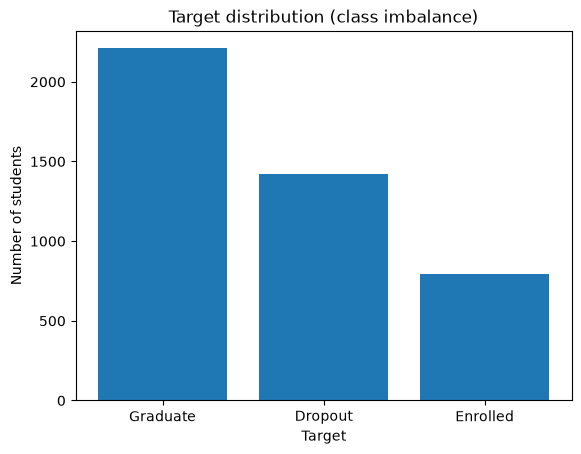

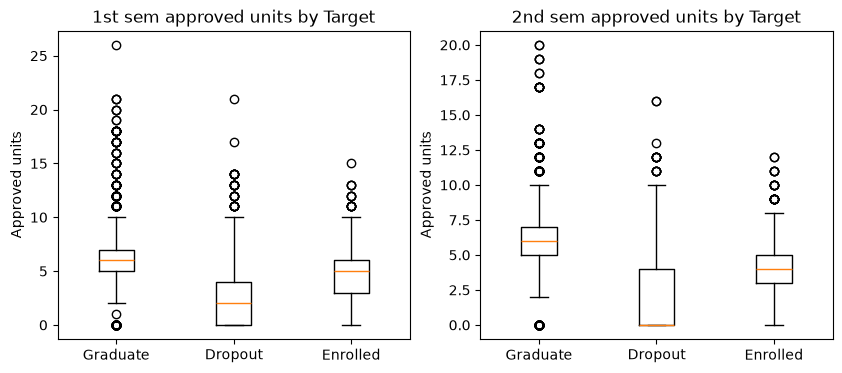

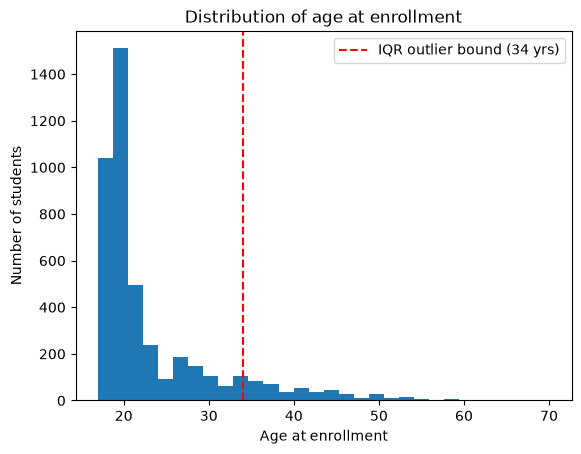

                                     Age at enrollment  Admission grade  \
Age at enrollment                                 1.00            -0.03   
Admission grade                                  -0.03             1.00   
Previous qualification (grade)                   -0.11             0.58   
Curricular units 1st sem (approved)              -0.05             0.07   
Curricular units 1st sem (grade)                 -0.16             0.07   
Curricular units 2nd sem (approved)              -0.11             0.08   
Curricular units 2nd sem (grade)                 -0.17             0.07   
Unemployment rate                                 0.03             0.04   
Inflation rate                                    0.03            -0.02   
GDP                                              -0.06            -0.02   

                                     Previous qualification (grade)  \
Age at enrollment                                             -0.11   
Admission grade                 

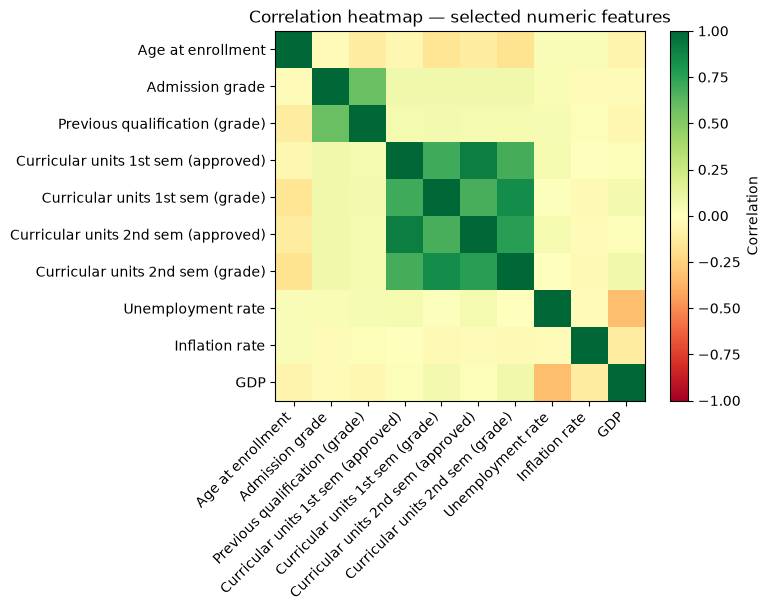

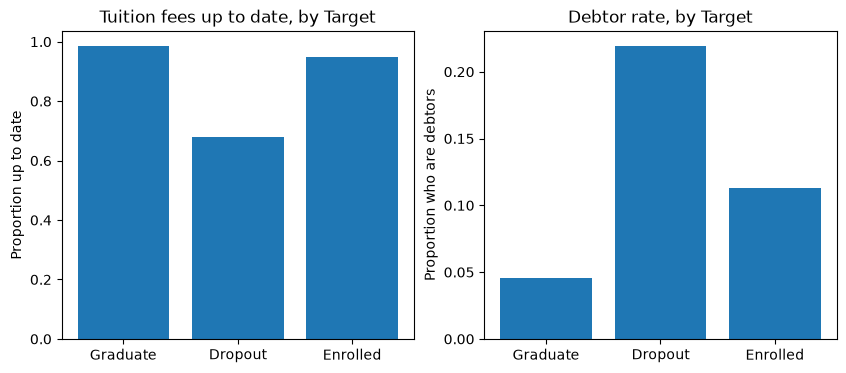

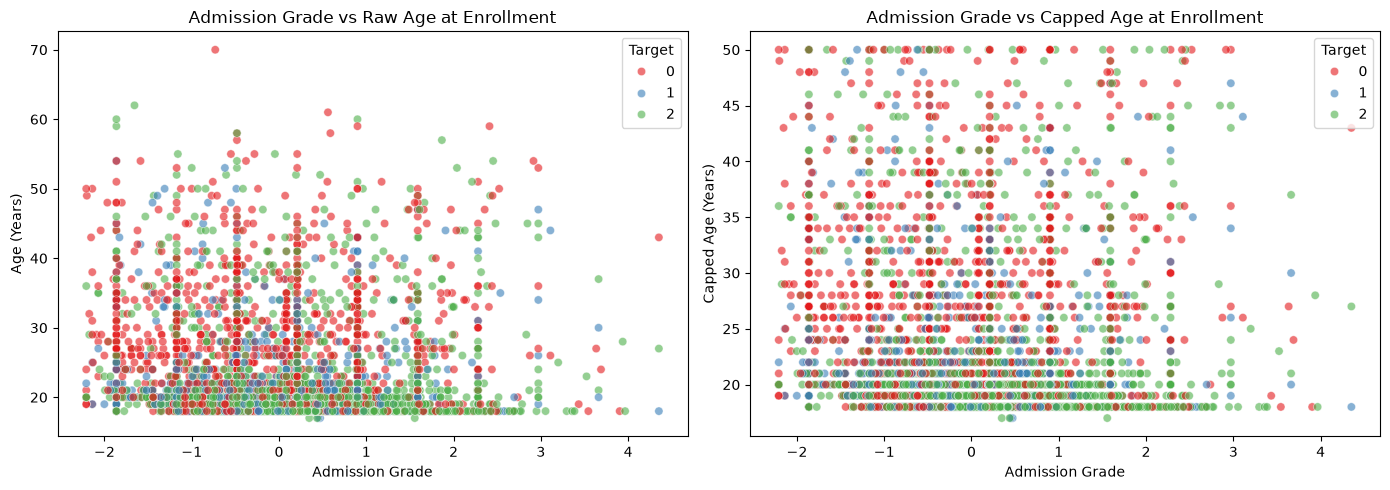

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Target was integer-encoded in Task 3.3 (0 = Dropout, 1 = Enrolled, 2 = Graduate)
target_labels = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
target_named = df_transformed["Target"].map(target_labels)
order = ["Graduate", "Dropout", "Enrolled"]

# 1) Target distribution
counts = target_named.value_counts().reindex(order)
plt.bar(counts.index, counts.values)
plt.xlabel("Target")
plt.ylabel("Number of students")
plt.title("Target distribution (class imbalance)")
plt.show()

# 2) Approved curricular units by Target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

groups_1st = [
    df_transformed.loc[target_named == t, "Curricular units 1st sem (approved)"]
    for t in order
]
axes[0].boxplot(groups_1st, tick_labels=order)
axes[0].set_title("1st sem approved units by Target")
axes[0].set_ylabel("Approved units")

groups_2nd = [
    df_transformed.loc[target_named == t, "Curricular units 2nd sem (approved)"]
    for t in order
]
axes[1].boxplot(groups_2nd, tick_labels=order)
axes[1].set_title("2nd sem approved units by Target")
axes[1].set_ylabel("Approved units")

plt.show()

# 3) Age at enrollment distribution
plt.hist(df_transformed["Age at enrollment"].dropna(), bins=30)
plt.axvline(34, color="red", linestyle="--", label="IQR outlier bound (34 yrs)")
plt.xlabel("Age at enrollment")
plt.ylabel("Number of students")
plt.title("Distribution of age at enrollment")
plt.legend()
plt.show()

# 4) Correlation heatmap for key numeric features
corr_cols = [
    "Age at enrollment", "Admission grade", "Previous qualification (grade)",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Unemployment rate", "Inflation rate", "GDP",
]

corr_matrix = df_transformed[corr_cols].corr()
print(corr_matrix.round(2))

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()
print(
    "Strongest absolute correlation:",
    strongest_pair,
    round(corr_matrix.loc[strongest_pair[0], strongest_pair[1]], 2),
)

plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation heatmap — selected numeric features")
plt.show()

# 5) Tuition fees up to date and Debtor status, by Target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

tuition_rate = df_transformed.groupby(target_named)["Tuition fees up to date"].mean().reindex(order)
axes[0].bar(tuition_rate.index, tuition_rate.values)
axes[0].set_title("Tuition fees up to date, by Target")
axes[0].set_ylabel("Proportion up to date")

debtor_rate = df_transformed.groupby(target_named)["Debtor"].mean().reindex(order)
axes[1].bar(debtor_rate.index, debtor_rate.values)
axes[1].set_title("Debtor rate, by Target")
axes[1].set_ylabel("Proportion who are debtors")

plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Admission Grade vs Raw Age
sns.scatterplot(
    ax=axes[0], data=df_transformed, 
    x='Admission grade', y='Age at enrollment', 
    hue='Target', alpha=0.6, palette='Set1'
)
axes[0].set_title('Admission Grade vs Raw Age at Enrollment')
axes[0].set_xlabel('Admission Grade')
axes[0].set_ylabel('Age (Years)')

# Plot 2: Admission Grade vs Capped Age
sns.scatterplot(
    ax=axes[1], data=df_transformed, 
    x='Admission grade', y='Age at enrollment_capped', 
    hue='Target', alpha=0.6, palette='Set1'
)
axes[1].set_title('Admission Grade vs Capped Age at Enrollment')
axes[1].set_xlabel('Admission Grade')
axes[1].set_ylabel('Capped Age (Years)')

plt.tight_layout()
plt.show()

### Figure interpretations

| Figure | What it shows | Interpretation |
|---|---|---|
| Target distribution | Bar chart of the three class counts (decoded from the 0/1/2 encoding) | The classes are imbalanced: Graduate 49.9%, Dropout 32.1%, Enrolled 17.9%. Any later modelling will need to account for this (e.g. class weights, stratified splits, or reporting per-class metrics) rather than relying on overall accuracy. |
| Approved units by Target (1st & 2nd sem) | Boxplots of approved curricular units, split by Target | Clear separation: Graduates cluster around 6 approved units both semesters with a narrow spread; Dropouts cluster much lower (median close to 0–2, especially in 2nd sem) with many at zero; Enrolled sits in between. About 51% of Dropouts have zero approved units in the 2nd semester versus only 3% of Graduates — this is the single strongest signal in the dataset. |
| Age at enrollment histogram | Distribution of enrollment age, with the Task 3.2 IQR outlier bound (34 years) marked | The distribution is right-skewed: most students enrol between 18–25 (median 20), but a long tail extends to 70. 441 students sit above the IQR bound of 34, and 225 are over 40. Task 3.2 chose to retain these values (mature students are a valid demographic) while also creating a 99th-percentile-capped column for sensitivity testing — that decision looks reasonable given how gradual the tail is here. |
| Correlation heatmap | Pairwise correlations among key numeric features (some now standardised) | The two "approved units" variables and their matching "grade" variables are strongly correlated with each other within a semester, as expected. Admission grade and previous qualification grade show a weaker positive correlation with in-course performance. Macroeconomic variables (unemployment, inflation, GDP) show little linear correlation with the academic variables — standardising the grade columns in Task 3.3 does not change any of these correlation values. |
| Tuition fees / Debtor status by Target | Bar charts of the proportion with fees up to date, and the proportion who are debtors, per Target class | Financial standing tracks strongly with outcome: 32% of Dropouts do not have tuition fees up to date compared with just 1.3% of Graduates, and 22% of Dropouts are debtors versus 4.6% of Graduates. This supports the "socio-economic factors" angle named in the problem statement. |
| Admission grade vs raw / capped age | Side-by-side scatter plots of (standardised) admission grade against raw age and 99th-percentile-capped age, coloured by Target | Older students are visible as a long tail in the raw-age plot. Capping at 50 compresses that tail but does not create a new grade–age pattern or change the Target colouring. That supports the Task 3.2 decision: keep the original ages as the default, and treat the capped column as an optional sensitivity check only. |


## 4.3 Analyse patterns


| Topic | Finding |
|---|---|
| Feature distributions | Most curricular-unit counts are roughly bell-shaped but with a spike at zero (students who enrolled in a semester but passed nothing). Age at enrollment is right-skewed (median 20, long tail to 70, IQR outlier bound at 34). Admission grade and the semester grades were standardised to z-scores in Task 3.3, so they are now centred at 0 with unit standard deviation by construction rather than sitting on their original 0–200 / 0–20 scales. |
| Missingness patterns | No missing values in `df_transformed` (`isna().sum().sum() == 0`) and no duplicate rows - confirmed again after the Task 3 cleaning/transformation steps, so nothing was introduced or lost along the way. |
| Target / class distribution | Imbalanced three-class target: Graduate 49.9% (2,209), Dropout 32.1% (1,421), Enrolled 17.9% (794). Task 3.3 re-encoded `Target` from text (Dropout/Enrolled/Graduate) to integers (0/1/2) for modelling readiness - the class sizes themselves are unchanged. |
| Key relationships | Curricular units approved (1st and 2nd sem) still show the strongest relationship with Target - Dropouts approve far fewer units than Graduates. Financial-standing variables (tuition fees up to date, debtor status, scholarship holder) also separate the classes clearly. The standardised Admission-grade and semester-grade z-scores follow the same ordering (Dropout lowest, Graduate highest), so scaling did not remove the signal, just changed its units. |
| Imbalance | The target class imbalance (roughly 2:1:1 for Graduate:Dropout:Enrolled) is moderate rather than extreme, but should still be handled explicitly in Phase II (e.g. stratified sampling, class weighting, or F1/recall-per-class reporting) rather than ignored. |
| Unusual patterns | About 16–20% of students have zero approved units in a semester despite being enrolled in units that semester - this "zero approved" group is disproportionately Dropouts (51% of Dropouts vs. 3% of Graduates have zero approved 2nd-sem units), suggesting it is a near-direct proxy for dropping out rather than a data-quality issue. Separately, 441 students (10%) sit above the IQR age outlier bound of 34 years - Task 3.2 retained these rather than treating them as errors, since a long tail of mature/returning students is expected in this context. |

## 4.4 Key data insights summary

1. **Structure:** `df_transformed` now has 4,424 records and 38 columns - the original 36 predictors plus `Target`, plus a new `Age at enrollment_capped` column created during outlier handling in Task 3.2. Two columns were renamed for clarity (`Nacionality` → `Nationality`, and the tab-formatted `Daytime/evening attendance` column cleaned up). `Target` is now an integer code (0 = Dropout, 1 = Enrolled, 2 = Graduate) rather than text, ready for modelling.
2. **Quality:** The dataset remains clean after cleaning/transformation - still no missing values and no duplicate rows. The main thing to keep in mind going forward is that Admission grade and the two semester-grade columns are now standardised z-scores (mean 0, std 1), not their original 0–200 / 0–20 scales, so any comparison against raw grade cut-offs needs to go back to `df_original`/`df_copy` instead.
3. **Usefulness for the problem:** The dataset is well suited to the stated objective of predicting dropout risk. Academic performance variables (approved units, standardised grades) and financial-standing variables (tuition status, debtor status, scholarship) all show strong, interpretable relationships with the target - exactly the kind of actionable signal an early-warning system would need, and the target encoding/scaling already done in Task 3 moves it a step closer to being modelling-ready.
4. **Limits / caveats:** The target class imbalance (50/32/18) means a naive model could score well on accuracy while doing poorly on the minority Dropout/Enrolled classes. The 2nd-semester academic variables are only available partway through the year, so a model meant for *early* intervention may need to rely more heavily on enrollment-time variables (demographics, admission grade, financial status) than on 2nd-semester performance. The dataset is also from a single Portuguese institution, so findings may not generalise elsewhere.
5. **Next steps after Phase I:** decide whether to use the raw or capped `Age at enrollment` column for modelling (Task 3.2 created both), extend the Task 3.3 encoding/scaling approach to the remaining categorical-coded integer columns (e.g. one-hot or ordinal encoding for course, occupation, qualification fields), and consider two modelling scenarios for Phase II - one using only enrollment-time features (true early prediction) and one including 1st/2nd-semester performance (higher accuracy, later intervention point).

# Data Key for Variables

Data dictionary copied from the dataset source page. All variable names, roles, types, demographics, descriptions, units, and missing-value notes are preserved as provided.

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| Marital Status | Feature | Integer | Marital Status | 1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated |  | no |
| Application mode | Feature | Integer |  | 1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - Holders of other higher courses 10 - Ordinance No. 854-B/99 15 - International student (bachelor) 16 - 1st phase - special contingent (Madeira Island) 17 - 2nd phase - general contingent 18 - 3rd phase - general contingent 26 - Ordinance No. 533-A/99, item b2) (Different Plan) 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 39 - Over 23 years old 42 - Transfer 43 - Change of course 44 - Technological specialization diploma holders 51 - Change of institution/course 53 - Short cycle diploma holders 57 - Change of institution/course (International) |  | no |
| Application order | Feature | Integer |  | Application order (between 0 - first choice; and 9 last choice) |  | no |
| Course | Feature | Integer |  | 33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance) |  | no |
| Daytime/evening attendance | Feature | Integer |  | 1 – daytime 0 - evening |  | no |
| Previous qualification | Feature | Integer | Education Level | 1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education - master's 5 - Higher education - doctorate 6 - Frequency of higher education 9 - 12th year of schooling - not completed 10 - 11th year of schooling - not completed 12 - Other - 11th year of schooling 14 - 10th year of schooling 15 - 10th year of schooling - not completed 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 42 - Professional higher technical course 43 - Higher education - master (2nd cycle) |  | no |
| Previous qualification (grade) | Feature | Continuous |  | Grade of previous qualification (between 0 and 200) |  | no |
| Nacionality | Feature | Integer | Nationality | 1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 - Cape Verdean; 24 - Guinean; 25 - Mozambican; 26 - Santomean; 32 - Turkish; 41 - Brazilian; 62 - Romanian; 100 - Moldova (Republic of); 101 - Mexican; 103 - Ukrainian; 105 - Russian; 108 - Cuban; 109 - Colombian |  | no |
| Mother's qualification | Feature | Integer | Education Level | 1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 22 - Technical-professional course 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized higher studies course 42 - Professional higher technical course 43 - Higher Education - Master (2nd cycle) 44 - Higher Education - Doctorate (3rd cycle) |  | no |
| Father's qualification | Feature | Integer | Education Level | 1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 13 - 2nd year complementary high school course 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 20 - Complementary High School Course 22 - Technical-professional course 25 - Complementary High School Course - not concluded 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 31 - General Course of Administration and Commerce 33 - Supplementary Accounting and Administration 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized higher studies course 42 - Professional higher technical course 43 - Higher Education - Master (2nd cycle) 44 - Higher Education - Doctorate (3rd cycle) |  | no |
| Mother's occupation | Feature | Integer | Occupation | 0 - Student 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 2 - Specialists in Intellectual and Scientific Activities 3 - Intermediate Level Technicians and Professions 4 - Administrative staff 5 - Personal Services, Security and Safety Workers and Sellers 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 7 - Skilled Workers in Industry, Construction and Craftsmen 8 - Installation and Machine Operators and Assembly Workers 9 - Unskilled Workers 10 - Armed Forces Professions 90 - Other Situation 99 - (blank) 122 - Health professionals 123 - teachers 125 - Specialists in information and communication technologies (ICT) 131 - Intermediate level science and engineering technicians and professions 132 - Technicians and professionals, of intermediate level of health 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 141 - Office workers, secretaries in general and data processing operators 143 - Data, accounting, statistical, financial services and registry-related operators 144 - Other administrative support staff 151 - personal service workers 152 - sellers 153 - Personal care workers and the like 171 - Skilled construction workers and the like, except electricians 173 - Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like 175 - Workers in food processing, woodworking, clothing and other industries and crafts 191 - cleaning workers 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 194 - Meal preparation assistants |  | no |
| Father's occupation | Feature | Integer | Occupation | 0 - Student 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 2 - Specialists in Intellectual and Scientific Activities 3 - Intermediate Level Technicians and Professions 4 - Administrative staff 5 - Personal Services, Security and Safety Workers and Sellers 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 7 - Skilled Workers in Industry, Construction and Craftsmen 8 - Installation and Machine Operators and Assembly Workers 9 - Unskilled Workers 10 - Armed Forces Professions 90 - Other Situation 99 - (blank) 101 - Armed Forces Officers 102 - Armed Forces Sergeants 103 - Other Armed Forces personnel 112 - Directors of administrative and commercial services 114 - Hotel, catering, trade and other services directors 121 - Specialists in the physical sciences, mathematics, engineering and related techniques 122 - Health professionals 123 - teachers 124 - Specialists in finance, accounting, administrative organization, public and commercial relations 131 - Intermediate level science and engineering technicians and professions 132 - Technicians and professionals, of intermediate level of health 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 135 - Information and communication technology technicians 141 - Office workers, secretaries in general and data processing operators 143 - Data, accounting, statistical, financial services and registry-related operators 144 - Other administrative support staff 151 - personal service workers 152 - sellers 153 - Personal care workers and the like 154 - Protection and security services personnel 161 - Market-oriented farmers and skilled agricultural and animal production workers 163 - Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence 171 - Skilled construction workers and the like, except electricians 172 - Skilled workers in metallurgy, metalworking and similar 174 - Skilled workers in electricity and electronics 175 - Workers in food processing, woodworking, clothing and other industries and crafts 181 - Fixed plant and machine operators 182 - assembly workers 183 - Vehicle drivers and mobile equipment operators 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 194 - Meal preparation assistants 195 - Street vendors (except food) and street service providers |  | no |
| Admission grade | Feature | Continuous |  | Admission grade (between 0 and 200) |  | no |
| Displaced | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Educational special needs | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Debtor | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Tuition fees up to date | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Gender | Feature | Integer | Gender | 1 – male 0 – female |  | no |
| Scholarship holder | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Age at enrollment | Feature | Integer | Age | Age of studend at enrollment |  | no |
| International | Feature | Integer |  | 1 – yes 0 – no |  | no |
| Curricular units 1st sem (credited) | Feature | Integer |  | Number of curricular units credited in the 1st semester |  | no |
| Curricular units 1st sem (enrolled) | Feature | Integer |  | Number of curricular units enrolled in the 1st semester |  | no |
| Curricular units 1st sem (evaluations) | Feature | Integer |  | Number of evaluations to curricular units in the 1st semester |  | no |
| Curricular units 1st sem (approved) | Feature | Integer |  | Number of curricular units approved in the 1st semester |  | no |
| Curricular units 1st sem (grade) | Feature | Integer |  | Grade average in the 1st semester (between 0 and 20) |  | no |
| Curricular units 1st sem (without evaluations) | Feature | Integer |  | Number of curricular units without evalutions in the 1st semester |  | no |
| Curricular units 2nd sem (credited) | Feature | Integer |  | Number of curricular units credited in the 2nd semester |  | no |
| Curricular units 2nd sem (enrolled) | Feature | Integer |  | Number of curricular units enrolled in the 2nd semester |  | no |
| Curricular units 2nd sem (evaluations) | Feature | Integer |  | Number of evaluations to curricular units in the 2nd semester |  | no |
| Curricular units 2nd sem (approved) | Feature | Integer |  | Number of curricular units approved in the 2nd semester |  | no |
| Curricular units 2nd sem (grade) | Feature | Integer |  | Grade average in the 2nd semester (between 0 and 20) |  | no |
| Curricular units 2nd sem (without evaluations) | Feature | Integer |  | Number of curricular units without evalutions in the 1st semester |  | no |
| Unemployment rate | Feature | Continuous |  | Unemployment rate (%) |  | no |
| Inflation rate | Feature | Continuous |  | Inflation rate (%) |  | no |
| GDP | Feature | Continuous |  | GDP |  | no |
| Target | Target | Categorical |  | Target. The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course |  | no |
